# Customer Churn Prediction

## Introduction

Customer churn is one of the most important challenges faced by banks and financial institutions.

When customers leave a bank and switch to another financial service provider, the organization may experience revenue loss, reduced customer loyalty, and increased costs associated with acquiring new customers.

Customer retention is generally more cost-effective than customer acquisition. Therefore, identifying customers who are likely to leave the bank is an important business objective.

With the help of data analysis and machine learning, it is possible to analyze customer information, identify patterns associated with customer behavior, and develop predictive models that estimate the likelihood of customer churn.

In this project, the Churn Modelling Dataset will be analyzed to understand customer characteristics, perform data cleaning, conduct exploratory data analysis (EDA), and develop classification models for predicting customer churn.

## Problem Statement

Customer churn is a major concern for banks and financial institutions because losing existing customers can negatively impact revenue, profitability, and long-term business growth.

Banks collect large amounts of customer information, including demographic details, account information, credit history, and banking activity. Analyzing this information can help identify customers who may be at risk of leaving the bank.

The objective of this project is to analyze customer data and identify the factors that influence customer churn.

Using historical customer records, machine learning models will be developed to predict whether a customer is likely to leave the bank.

The final model will be evaluated using classification performance metrics to measure its predictive capability and effectiveness.

## Project Objectives

The main objectives of this project are:

- Understand the structure and contents of the dataset
- Explore customer demographic and banking information
- Identify and handle missing values
- Perform data cleaning and preparation
- Encode categorical variables
- Conduct exploratory data analysis (EDA)
- Visualize important features affecting customer churn
- Build a machine learning classification model
- Evaluate model performance using classification metrics
- Analyze feature importance
- Generate meaningful insights from the analysis

## Dataset Information

This project uses the **Churn Modelling Dataset** obtained from Kaggle.

**Dataset Source:**  
https://www.kaggle.com/datasets/shrutimechlearn/churn-modelling

The dataset contains customer demographic information, banking details, account activity, and churn status records.

The primary objective of this dataset is to analyze customer behavior and identify factors that influence customer churn.

Each record represents an individual bank customer and contains information such as credit score, geography, gender, age, account balance, tenure, number of products, and estimated salary.

The target variable in this dataset is **Exited**, which indicates whether a customer left the bank or remained with the bank.

### Target Variable

| Value | Meaning |
|---------|---------|
| 0 | Customer Stayed |
| 1 | Customer Churned |

### Dataset Summary

| Attribute | Description |
|------------|------------|
| Dataset Name | Churn Modelling Dataset |
| Source | Kaggle |
| File Used | Churn_Modelling.csv |
| Problem Type | Binary Classification |
| Target Variable | Exited |
| Domain | Banking and Finance |

## Dataset Understanding and Description

Understanding the dataset is an important first step before data cleaning, analysis, and model development.

This project uses the Churn Modelling Dataset, which contains customer demographic information, financial details, and account-related attributes.

The objective is to predict whether a customer is likely to leave the bank based on customer characteristics and banking behavior.

### Dataset Features

| Feature | Description |
|----------|-------------|
| RowNumber | Record index number |
| CustomerId | Unique customer identifier |
| Surname | Customer surname |
| CreditScore | Customer credit score |
| Geography | Customer country/location |
| Gender | Customer gender |
| Age | Customer age |
| Tenure | Number of years with the bank |
| Balance | Account balance |
| NumOfProducts | Number of bank products used |
| HasCrCard | Credit card ownership status |
| IsActiveMember | Active membership status |
| EstimatedSalary | Estimated annual salary |
| Exited | Target variable indicating customer churn |

## Import Required Libraries

Before starting the analysis and machine learning process, the required Python libraries are imported.

These libraries provide functionalities for data loading, preprocessing, visualization, model development, feature importance analysis, and performance evaluation.

Pandas and NumPy are used for data manipulation and numerical operations.

Matplotlib and Seaborn are used for data visualization and exploratory data analysis.

Scikit-learn libraries are used for dataset splitting, machine learning model training, feature importance analysis, and model performance evaluation.

In [1]:
# Data manipulation and analysis

import pandas as pd
import numpy as np

# Data visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Dataset splitting

from sklearn.model_selection import train_test_split

# Machine learning model

from sklearn.ensemble import RandomForestClassifier

# Model evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

## Load Dataset

The Churn Modelling Dataset is loaded into a Pandas DataFrame for analysis.

A DataFrame is a tabular data structure consisting of rows and columns, similar to an Excel spreadsheet. It allows efficient data exploration, manipulation, and analysis.

A copy of the original dataset is also created to preserve the raw data while performing cleaning and preprocessing operations.

In [20]:
# Load dataset into a Pandas DataFrame

df = pd.read_csv("../datasets/Churn_Modelling.csv")

# Create a copy of the original dataset

# df_clean = df.copy()

## Dataset Preview

After loading the dataset, the first five records are displayed to verify that the dataset has been loaded successfully and to gain an initial understanding of its structure.

In [21]:
# Display first five records

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [22]:
# Display the first five records of the dataset

df_clean.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Data Cleaning and Preparation

Data cleaning is an important step in the machine learning workflow.

The objective of this phase is to identify missing values, verify dataset quality, and prepare the data for analysis and model development.

### Dataset Shape

Understanding the size of the dataset is an important step before performing data cleaning and analysis.

The shape of the dataset provides information about the total number of records and features available for customer churn prediction. This helps estimate the overall dataset size and understand the amount of information available for model development.

In [23]:
# Display the number of rows and columns in the dataset

print("Number of Rows and Columns:", df.shape)

Number of Rows and Columns: (10000, 14)


#### Observation

The dataset contains 10,000 rows and 14 columns.

Each row represents an individual bank customer, while each column represents a specific customer attribute such as demographic information, financial details, account activity, or churn status.

The dataset provides sufficient information for exploratory data analysis and machine learning model development.

With 10,000 customer records available, the dataset is suitable for building and evaluating customer churn prediction models.

### Dataset Information

Dataset information provides a detailed overview of the structure of the dataset.

This analysis helps identify data types, non-null values, and potential missing data issues that may require preprocessing before model training.

In [24]:
# Display information about the dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


#### Observation

The dataset contains 10,000 customer records and 14 features.

All features contain 10,000 non-null values, indicating that the dataset does not contain any missing values.

The dataset consists of both numerical and categorical variables.

Categorical features include Surname, Geography, and Gender, while the remaining features are numerical in nature.

The target variable, Exited, is represented as an integer variable and indicates whether a customer left the bank or remained with the bank.

The dataset occupies approximately 1.1 MB of memory and is suitable for exploratory data analysis and machine learning model development.

### Missing Values Analysis

Missing values are commonly found in real-world datasets and can affect the performance of machine learning models.

Before proceeding with analysis and model development, it is important to identify the amount of missing data present in each feature.

This analysis helps determine whether data cleaning and imputation techniques are required before model training.

In [25]:
# Display the number of missing values in each column

df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

#### Observation

The missing values analysis confirms that the dataset does not contain any missing values.

All 14 features contain complete information for all 10,000 customer records.

Since no missing values are present, no imputation or missing value handling techniques are required during the data cleaning process.

This indicates that the dataset is complete and ready for further preprocessing, exploratory data analysis, and machine learning model development.

### Duplicate Records Analysis

Duplicate records can affect dataset quality and lead to biased analytical results.

Therefore, the dataset is checked for duplicate entries to ensure that each record represents a unique customer before proceeding with further preprocessing and model development.

In [26]:
# Calculate the total number of duplicate records

print("Duplicate Records:",df.duplicated().sum())

Duplicate Records: 0


#### Observation

The duplicate records analysis confirms that no duplicate entries are present in the dataset.

Each record represents a unique bank customer, indicating that the dataset maintains good data quality and consistency.

Since no duplicate records were identified, no duplicate removal was required during the preprocessing stage.

### Encoding Categorical Variables

Machine learning algorithms require numerical input and cannot directly process categorical text values.

Therefore, categorical features must be converted into numerical representations before model training.

Before encoding, the unique values of each categorical feature are examined to understand the categories present in the dataset.

In [28]:
# Display unique values of categorical features

categorical_columns = [
    "Geography",
    "Gender"
]

for column in categorical_columns:
    print(f"{column}: {df[column].unique().tolist()}")

Geography: ['France', 'Spain', 'Germany']
Gender: ['Female', 'Male']


#### Observation

The categorical features contain a limited number of distinct categories, making them suitable for encoding.

The Gender feature contains two categories: Male and Female.

The Geography feature contains three categories: France, Spain, and Germany.

Since machine learning algorithms require numerical input, these categorical values will be converted into numerical representations during the encoding stage.

#### Encode Gender Feature

The Gender feature contains two categories and can be converted into numerical values using binary encoding.

Male customers will be represented as 1, while Female customers will be represented as 0.

This transformation allows the feature to be used by machine learning algorithms.

In [29]:
# Encode Gender feature

df_clean["Gender"] = df_clean["Gender"].map({
    "Male": 1,
    "Female": 0
})

#### Encode Geography Feature

The Geography feature contains multiple categories with no natural order or ranking.

Therefore, One-Hot Encoding is applied to create separate binary variables for each category and avoid introducing artificial relationships between locations.

The first category is dropped to prevent multicollinearity and reduce redundancy.

In [30]:
# Apply One-Hot Encoding to Geography

df_clean = pd.get_dummies(
    df_clean,
    columns=["Geography"],
    drop_first=True,
    dtype=int
)

#### Verify Encoded Values

After encoding, the dataset is reviewed to confirm that the categorical features have been successfully converted into numerical values.

This verification step ensures that the dataset is ready for machine learning algorithms.

In [31]:
# Display first ten records after encoding

df_clean.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,1,15634602,Hargrave,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,2,15647311,Hill,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,3,15619304,Onio,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,4,15701354,Boni,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,5,15737888,Mitchell,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1
5,6,15574012,Chu,645,1,44,8,113755.78,2,1,0,149756.71,1,0,1
6,7,15592531,Bartlett,822,1,50,7,0.00,2,1,1,10062.80,0,0,0
7,8,15656148,Obinna,376,0,29,4,115046.74,4,1,0,119346.88,1,1,0
8,9,15792365,He,501,1,44,4,142051.07,2,0,1,74940.50,0,0,0
9,10,15592389,H?,684,1,27,2,134603.88,1,1,1,71725.73,0,0,0


##### Observation

The categorical features were successfully converted into numerical representations.

The Gender feature was encoded using binary encoding, where Male is represented as 1 and Female is represented as 0.

The Geography feature was encoded using One-Hot Encoding. Since the first category was dropped to avoid multicollinearity, two new binary variables were created: Geography_Germany and Geography_Spain.

Customers belonging to France are represented when both Geography_Germany and Geography_Spain contain a value of 0.

The dataset is now suitable for machine learning algorithms that require numerical input features.

### Remove Unnecessary Features

Some features do not provide meaningful information for predicting customer churn.

RowNumber is simply a record index, CustomerId is a unique customer identifier, and Surname contains customer names.

These features do not contribute to customer churn prediction and may introduce unnecessary complexity into the model.

Therefore, they will be removed before further analysis and model development.

In [32]:
# Remove unnecessary features

df_clean = df_clean.drop(
    ["RowNumber", "CustomerId", "Surname"],
    axis=1
)

#### Verify Column Removal

The column names are displayed to confirm that the unnecessary features have been successfully removed from the dataset.

In [33]:
# Display column names after removing unnecessary features

df_clean.columns.tolist()

['CreditScore',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited',
 'Geography_Germany',
 'Geography_Spain']

##### Observation

The unnecessary features were successfully removed from the dataset.

The RowNumber feature was removed because it only represents the record index and does not contain predictive information.

The CustomerId feature was removed because it is a unique identifier and does not contribute to customer churn prediction.

The Surname feature was removed because customer names do not provide meaningful information for predicting churn behavior.

The remaining features consist of customer demographic information, financial attributes, banking activity indicators, and the target variable required for machine learning model development.

### Final Dataset Check

A final review of the dataset is performed after preprocessing to ensure that categorical variables have been encoded and unnecessary features have been removed.

This verification confirms that the dataset is ready for exploratory data analysis and machine learning model development.

In [34]:
# Display dataset information after preprocessing

df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Gender             10000 non-null  int64  
 2   Age                10000 non-null  int64  
 3   Tenure             10000 non-null  int64  
 4   Balance            10000 non-null  float64
 5   NumOfProducts      10000 non-null  int64  
 6   HasCrCard          10000 non-null  int64  
 7   IsActiveMember     10000 non-null  int64  
 8   EstimatedSalary    10000 non-null  float64
 9   Exited             10000 non-null  int64  
 10  Geography_Germany  10000 non-null  int64  
 11  Geography_Spain    10000 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 937.6 KB


#### Observation

The final dataset contains 10,000 customer records and 12 features after preprocessing.

All categorical variables have been successfully converted into numerical representations using binary encoding and One-Hot Encoding techniques.

The unnecessary features (RowNumber, CustomerId, and Surname) were removed because they do not contribute to customer churn prediction.

The dataset now consists entirely of numerical variables, including 10 integer features and 2 floating-point features.

With no missing values and all features in a machine-learning-friendly format, the dataset is fully prepared for exploratory data analysis and predictive modeling.

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the characteristics, patterns, and relationships within the dataset.

Through statistical summaries and visualizations, EDA helps identify important trends, distributions, and factors that may influence customer churn behavior.

The insights gained from this analysis can support feature understanding and improve machine learning model development.

### Descriptive Statistics

Descriptive statistics provide a summary of the numerical features in the dataset.

These statistics help understand the central tendency, variability, and overall distribution of the data by presenting measures such as count, mean, standard deviation, minimum value, maximum value, and quartiles.

This analysis provides an initial understanding of the dataset before performing detailed visualizations and feature-level exploration.

In [35]:
# Generate descriptive statistics for numerical features

df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Gender,10000.0,0.545700,0.497932,0.00,0.00,1.000,1.0000,1.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
HasCrCard,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
IsActiveMember,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Exited,10000.0,0.203700,0.402769,0.00,0.00,0.000,0.0000,1.00


#### Observation

The descriptive statistics provide an overview of the numerical features in the dataset.

The dataset contains 10,000 customer records, and all features have complete observations after preprocessing.

The average credit score is approximately 650, with values ranging from 350 to 850.

The average customer age is approximately 39 years, with ages ranging from 18 to 92 years.

Customers have an average tenure of approximately 5 years with the bank, while the number of products used by customers ranges from 1 to 4.

The average account balance is approximately 76,486, although some customers have a zero balance while the maximum balance exceeds 250,000.

The average estimated salary is approximately 100,090, with salaries ranging from 11.58 to nearly 200,000.

The target variable (Exited) has a mean value of 0.204, indicating that approximately 20% of customers in the dataset have churned, while the remaining customers stayed with the bank.

Overall, the descriptive statistics suggest substantial variation in customer demographics and financial characteristics, making the dataset suitable for customer churn analysis and predictive modeling.

### Customer Churn Distribution

The Exited feature is the target variable of the dataset.

Analyzing its distribution helps understand the proportion of customers who remained with the bank and those who left the bank.

Understanding the target variable distribution is important for evaluating class balance and model performance.

In [36]:
# Calculate customer churn distribution

df_clean["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

#### Observation

The target variable distribution shows that 7,963 customers remained with the bank, while 2,037 customers left the bank.

This indicates that the dataset is imbalanced, with customer retention being significantly more common than customer churn.

Approximately 79.6% of customers remained with the bank, whereas 20.4% of customers exited.

Understanding this distribution is important because class imbalance can influence machine learning model performance and evaluation.

#### Customer Churn Distribution Visualization

A bar chart is used to visualize the distribution of customers who remained with the bank and those who exited.

This visualization provides a clear comparison between the two target classes and helps assess class balance within the dataset.

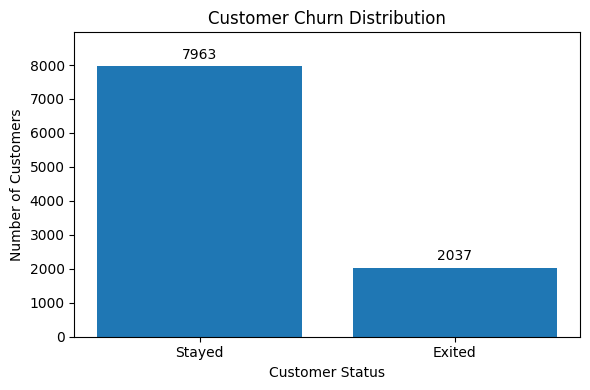

In [63]:
# Calculate churn distribution

churn_counts = df_clean["Exited"].value_counts()

# Create bar chart

plt.figure(figsize=(6,4))

bars = plt.bar(
    ["Stayed", "Exited"],
    [
        churn_counts[0],
        churn_counts[1]
    ]
)

# Add data labels

plt.bar_label(bars, padding=3)

# Add extra space at top

plt.ylim(0, max(churn_counts) + 1000)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

# Save figure

plt.tight_layout()

plt.show()

##### Observation

The visualization shows that the majority of customers remained with the bank.

Out of 10,000 customers, 7,963 remained with the bank, while 2,037 customers exited.

Approximately 79.6% of customers stayed with the bank, whereas 20.4% of customers left the bank.

This indicates a noticeable class imbalance in the target variable, with customer retention being significantly more common than customer churn.

Although the dataset is imbalanced, both classes contain a sufficient number of observations for machine learning model training and evaluation.

Understanding this distribution is important because customer churn prediction models must correctly identify the smaller churned customer group despite the dominance of retained customers.

### Gender Distribution

Gender is an important demographic feature in the dataset.

Analyzing the gender distribution helps understand the representation of male and female customers and provides insight into the composition of the customer base.

In [64]:
# Calculate gender distribution

df_clean["Gender"].value_counts()

Gender
1    5457
0    4543
Name: count, dtype: int64

#### Observation

The gender distribution shows that 5,457 customers are male, while 4,543 customers are female.

Male customers account for approximately 54.6% of the dataset, whereas female customers represent approximately 45.4%.

The distribution is relatively balanced, with a slightly higher proportion of male customers.

This balanced representation ensures that both gender groups are adequately represented for customer churn analysis and machine learning model development.

#### Gender Distribution Visualization

A bar chart is used to visualize the distribution of male and female customers.

This visualization provides a clear comparison between the two gender categories and helps understand the composition of the customer base.

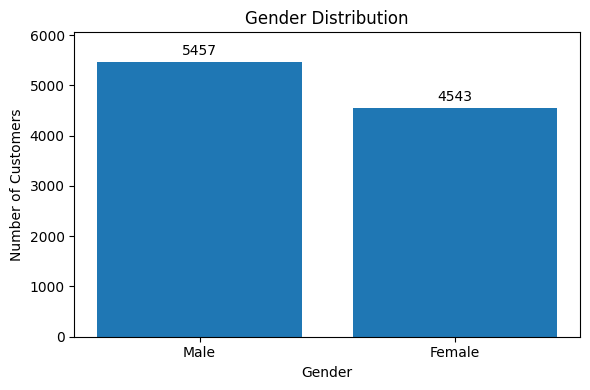

In [69]:
# Calculate gender distribution

gender_counts = df_clean["Gender"].value_counts()

# Create bar chart

plt.figure(figsize=(6,4))

bars = plt.bar(
    ["Male", "Female"],
    [
        gender_counts[1],
        gender_counts[0]
    ]
)

# Add data labels

plt.bar_label(bars, padding=3)

# Add extra space at top

plt.ylim(0, max(gender_counts) + 600)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

# Save figure

plt.tight_layout()

plt.show()

##### Observation

The visualization shows that male customers slightly outnumber female customers in the dataset.

Out of 10,000 customers, 5,457 are male and 4,543 are female.

Male customers account for approximately 54.6% of the customer base, while female customers represent approximately 45.4%.

The difference between the two groups is relatively small, indicating a fairly balanced gender distribution.

This balanced representation allows customer churn patterns to be analyzed across both gender groups without significant bias caused by unequal sample sizes.

### Customer Churn by Gender

Analyzing customer churn across gender categories helps determine whether gender has any relationship with customer retention behavior.

This analysis compares the number of customers who remained with the bank and those who exited within each gender group.

In [77]:
# Create churn by gender table

gender_churn = pd.crosstab(
    df_clean["Gender"],
    df_clean["Exited"]
)

gender_churn.index = [
    "Female(0)", 
    "Male(1)"
]

gender_churn.columns = [
    "Stayed(0)",
    "Exited(1)"
]

gender_churn

,Stayed(0),Exited(1)
Female(0),3404,1139
Male(1),4559,898


#### Observation

The churn analysis by gender shows that both male and female customers experienced customer churn.

Among female customers, 3,404 remained with the bank while 1,139 exited.

Among male customers, 4,559 remained with the bank while 898 exited.

Although male customers constitute a larger portion of the customer base, female customers have a higher number of churned customers relative to their population.

These results suggest that gender may have an influence on customer retention behavior and should be further explored through visualization and predictive modeling.

#### Customer Churn by Gender Visualization

A grouped bar chart is used to compare customer retention and churn across gender categories.

This visualization provides a side-by-side comparison of customers who remained with the bank and those who exited within each gender group.

The chart helps identify differences in churn behavior between male and female customers and provides a clearer understanding of the relationship between gender and customer churn.

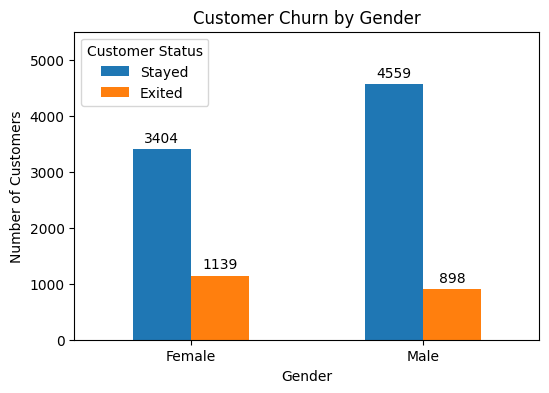

In [108]:
# Create bar chart

ax = gender_churn.plot(
    kind="bar",
    figsize=(6,4)
)

ax.set_xticklabels(
    ["Female", "Male"],
    rotation=0
)

# Add data labels

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(
    title="Customer Status",
    labels=["Stayed", "Exited"]
)

# Add extra space at top

plt.ylim(0, 5500)

plt.show()

##### Observation

The visualization compares customer retention and churn across gender categories.

Among female customers, 3,404 remained with the bank while 1,139 exited.

Among male customers, 4,559 remained with the bank while 898 exited.

The number of churned female customers is higher than the number of churned male customers, despite female customers representing a smaller portion of the customer base.

Similarly, male customers have a higher number of retained customers, which is consistent with their larger representation in the dataset.

These findings suggest that gender may have an influence on customer churn behavior and should be further investigated during predictive modeling and feature importance analysis.